# **0. - Machine Learning No Supervisado**

El Machine Learning supervisado permite crear modelos de clasificación de palabras y tokens. Esto requiere tener corpus etiquetados, sin embargo, muchas veces es difícil tener corpus etiquetados. El machine learning no supervisado permite extraer información de corpus que no tienen ningún tipo de etiqueta

## Caso Real: Wikipedia

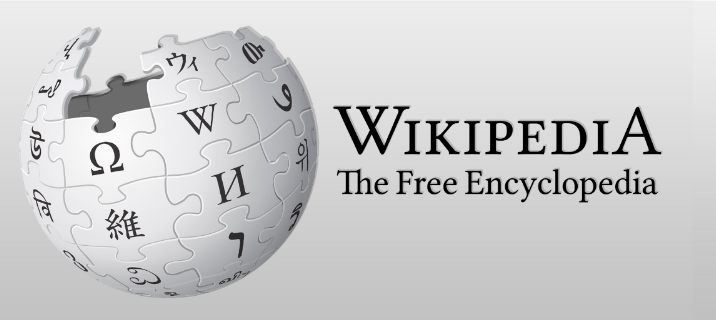

A partir de los 2000 hemos vivido el boom de la digitalización. Cada vez se almacenaba más y más información que muchas veces está enlazada con otra. Para ello wikipedia construyó grafos de conocimiento, capaces de linkar una información con otra y construir relaciones entre ellas. Cada artículo representa una entidad o concepto conectado con otros mediante enlaces semánticos. Más adelante, estos vínculos conceptuales y estructurados sentaron las bases para la creación de Wikidata (2012)

## Tipos de ML no supervisado en lenguaje

En el campo del lenguaje computacional, algunos tipos de aprendizaje no supervisado son los siguientes


* **Topic Modelling (Clustering)**: Un tipo de clusterización que tiene como objetivo "detectar" temáticas similares en documentos


* **Information Retrieval (Sistemas de recomendación)**: Como ya vimos, este tipo de sistemas tienen como objetivo buscar un texto parecido a otro dado.


* **Grafos de conocimiento**: Aunque no es exactamente ML, puede considerarse un tipo de aprendizaje no supervisado que tiene como objetivo "extraer" entiedades de un texto y las relaciones que existen entre ellas.

---

# **1. Grafos de conocimiento**

Un grafo de conocimiento es una estructura que representa conocimiento de manera organizada, usando nodos y aristas para mostrar conceptos y sus relaciones semánticas.


* **Nodos**: representan entidades o conceptos, como  "José Arcadio, “Macondo” o "Persona"


* **Enlaces**: representan relaciones entre esos conceptos, como “hijo de", “vive en” o "es un tipo de".


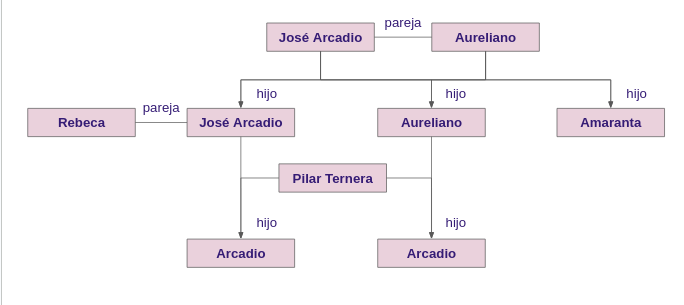

Aunque es posible definir un grafo de conocimiento, generalmente se construyen de manera automática a partir de procesar un corpus

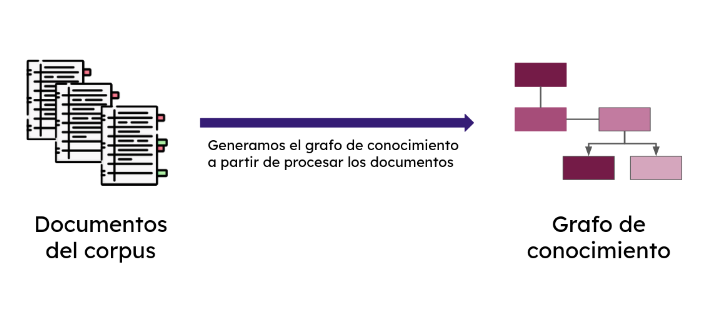

<br>

## **1.1. - Corpus No Etiquetado**

### Corpus - 100 años de soledad

In [1]:
import requests

# Web con el libro en txt
web = "https://gist.githubusercontent.com/ismaproco/6781d297ee65c6a707cd3c901e87ec56/raw/20d3520cd7c53d99215845375b1dca16ac827bd7/gabriel_garcia_marquez_cien_annos_soledad.txt"

# Descargamos con la librería request
response = requests.get(web)

# Recojemos el texto de descarga
text = response.text

# Pie de página
pie_de_pagina = "\n\n\nCien años de soledad \n\n\n\nGabriel García Márquez \n\n"

# Dividimos por pie de página
corpus = text.split(pie_de_pagina)[1:]

# Juntamos y dividimos por frase
corpus=' '.join(corpus).replace('\n','').split('. ')

corpus[0:5]

['Muchos años después, frente al pelotón de fusilamiento, el coronel Aureliano Buendía había de recordar aquella tarde remota en que su padre lo llevó a conocer el hielo',
 'Macondo era entonces una aldea de veinte casas de barro y cañabrava construidas a la orilla de un río de aguas diáfanas que se precipitaban por un lecho de piedras pulidas, blancas y enormes como huevos prehistóricos',
 'El mundo era tan reciente, que muchas cosas carecían de nombre, y para mencionarlas había que señalarías con el dedo',
 'Todos los años, por el mes de marzo, una familia de gitanos desarrapados plantaba su carpa cerca de la aldea, y con un grande alboroto de pitos y timbales daban a conocer los nuevos inventos',
 'Primero llevaron el imán']

### **Preprocesamiento**

**Ejercicio** Antes de ponernos a escribir líneas vamos a pensar ¿Qué tipo de preprocesamiento es necesario para este problema? Para ello vamos a pensar qué vamos a hacer



* Vamos a usar el NER de Spacy para detectar entidades

* Vamos a usar el POS de Spacy para detectar relaciones

* A partir del POS vamos a definir cómo relacionar las entidades

In [2]:
def preprocess(text):


    # ¿Es necesario algún preprocesamiento? Puede que no


    return text


corpus = [preprocess(text) for text in corpus]


corpus[0:5]

['Muchos años después, frente al pelotón de fusilamiento, el coronel Aureliano Buendía había de recordar aquella tarde remota en que su padre lo llevó a conocer el hielo',
 'Macondo era entonces una aldea de veinte casas de barro y cañabrava construidas a la orilla de un río de aguas diáfanas que se precipitaban por un lecho de piedras pulidas, blancas y enormes como huevos prehistóricos',
 'El mundo era tan reciente, que muchas cosas carecían de nombre, y para mencionarlas había que señalarías con el dedo',
 'Todos los años, por el mes de marzo, una familia de gitanos desarrapados plantaba su carpa cerca de la aldea, y con un grande alboroto de pitos y timbales daban a conocer los nuevos inventos',
 'Primero llevaron el imán']

<br>

## **1.2. - Grafo**

### Extracción de conceptos y relaciones

EL grafo de conocimiento se construye a partir de los enlaces semánticos. Los enlaces semánticosson una tríada **Concepto-Relación-Concetpo**

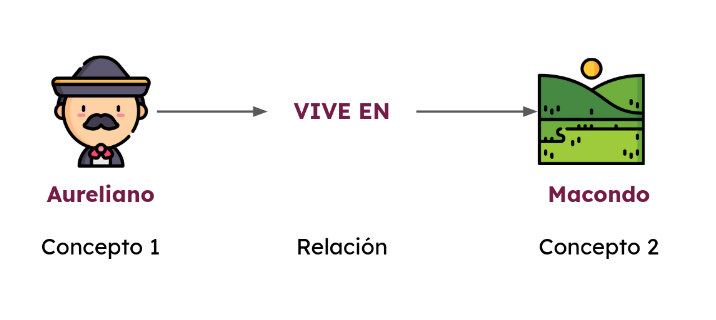

Un problema común cuando se tiene gran cantidad de datos de caracter de lenguaje es poder "extraer" de alguna forma el conocimiento ontológico que contiene (entidades, relaciones, taxonomías). Los grafos de conocimiento son un tipo de Machine Learning que permite extraer este tipo de información apoyándose en otras técnicas como:


* **NER y POS**: Con el objetivo de poder extraer entidades y relaciones, muchas veces se usa este tipo de herramientas. A partir del NER extraemos las entidades y del POS la relación entre ellos a partir de la función sintáctica


* **Expresiones regulares**: En problemas de lenguaje muy reglado (por ejemplo procesando archivos como xml) es común usar expresiones regulares para detectar las entidades y las relaciones a partir de la estructura del fichero


* **Ontologías**: ontologias como wordnet nos permiten también detectar entidades y funciones sintáctias entre términos de frases

**Procesamiento con Spacy**

Como ya hemos visto, Spacy nos permite procesar texto para ver las dependencias que existen entre diferentes palabras (dependencies graph)

In [3]:
!python -m spacy download es_core_news_sm

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.9/12.9 MB 29.4 MB/s eta 0:00:00a 0:00:01
✔ Download and installation successful
You can now load the package via spacy.load('es_core_news_sm')


In [4]:
import spacy
import pandas as pd
from tqdm import tqdm


nlp = spacy.load("es_core_news_sm")
doc = nlp(corpus[0])

data = []
for token in doc:
    data.append(
        {
            "token":token.text,
            "pos": token.pos_,
            "dep": token.dep_,
        }
    )

pd.DataFrame(data).head(10)

,token,pos,dep
0,Muchos,DET,det
1,años,NOUN,obl
2,después,ADV,advmod
3,",",PUNCT,punct
4,frente,NOUN,case
5,al,DET,det
6,pelotón,NOUN,obl
7,de,ADP,case
8,fusilamiento,NOUN,nmod
9,",",PUNCT,punct


**Relación: Sujeto-Predicado**

In [5]:
import spacy


from tqdm import tqdm

def get_matches(corpus):

    nlp = spacy.load("es_core_news_sm")

    matches = []


    for sentence in tqdm(corpus):

        doc = nlp(sentence)
        sub = None
        obj = None
        for token in doc:

            if "subj" in token.dep_ and token.ent_type_ in ['PER',"LOC"] and token.text[0].isupper():
                sub = token.text

            if "obj" in token.dep_  and token.ent_type_ in ['PER', "LOC"]  and token.text[0].isupper():
                obj = token.text

            relation = ''

        if sub and obj and sub!=obj:
            matches.append([sub, relation, obj])

    return matches

matches = get_matches(corpus)

pd.DataFrame(matches[0:10],columns=["Concepto","Relación","Concepto"])

100%|██████████| 5219/5219 [00:41<00:00, 125.95it/s]


,Concepto,Relación,Concepto
0,José,,Melquíades
1,Francis,,Riohacha
2,Úrsula,,Prudencio
3,José,,Prudencio
4,Pilar,,Úrsula
5,Dios,,José
6,Úrsula,,Buendía
7,Pilar,,José
8,Remedios,,Aureliano
9,Arcadio,,Aureliano


<br>

### Construcción del grafo

Vamos a usar una librería en Python que vale exactamente para esto "networkx", no es muy necesario conocerla ni saber usarla (yo he buscado como usarla en Google porque tampoco sé). Solo saber que existe para estos problemas

In [6]:
!pip install -q networkx

import networkx as nx

def get_graph(matches: list[list[str]]):

    G = nx.DiGraph()

    for item in matches:

        sub = item[0]

        rel = item[1]

        obj = item[2]

        G.add_edge(sub, obj, label='')

    return G

G = get_graph(matches)
G

<br>

### Visualizar el grafo

Esta función no hace falta entenderla (yo la he hecho con chatGPT)

In [7]:
import plotly.graph_objects as go

def get_graph(graph: nx.DiGraph):

    pos = nx.fruchterman_reingold_layout(G, k=0.5)

    # Create edge traces
    edge_traces = []
    for edge in G.edges():
        x0, y0 = pos[edge[0]]
        x1, y1 = pos[edge[1]]
        edge_trace = go.Scatter(
            x=[x0, x1, None],
            y=[y0, y1, None],
            mode='lines',
            line=dict(width=0.5, color="gray"),
            hoverinfo="none"
         )
        edge_traces.append(edge_trace)

    # Create node trace
    node_trace = go.Scatter(
        x=[pos[node][0] for node in G.nodes()],
        y=[pos[node][1] for node in G.nodes()],
        mode="markers+text",
        marker=dict(size=10, color="lightblue"),
        text=[node for node in G.nodes()],
        textposition="top center",
        hoverinfo="text",
        textfont=dict(size=12)
    )

    # Create edge label trace
    edge_label_trace = go.Scatter(
        x=[(pos[edge[0]][0] + pos[edge[1]][0]) / 2 for edge in G.edges()],
        y=[(pos[edge[0]][1] + pos[edge[1]][1]) / 2 for edge in G.edges()],
        mode="text",
        text=[G[edge[0]][edge[1]]["label"] for edge in G.edges()],
        textposition="middle center",
        hoverinfo="none",
        textfont=dict(size=7)
    )

    # Create layout
    layout = go.Layout(
        title="Knowledge Graph",
        title_x=0.5,
        showlegend=False,
        hovermode="closest",
        margin=dict(b=20, l=5, r=5, t=40),
        xaxis_visible=False,
        yaxis_visible=False
    )

    # Create Plotly figure
    fig = go.Figure(data=edge_traces + [node_trace, edge_label_trace], layout=layout)

    # Show the interactive plot
    fig.show()

get_graph(G)

### Ejercicio - Mejora del grafo de 100 años de soledad

* **Setear relación**: Dentro de la función get matches(corpus) hay una variable que no seteamos. Define su valor para que refleje la relación entre las entidades (por ejemplo el verbo de la frase)


* **Entidades de lugar**: Ahora el grafo de conocimiento solo extrae entidades de persona. Cámbialo para que también tenga en cuenta entidades de lugar

---

# **2. - Topic Modeling**

El topic modelling es un tipo de problema del lenguaje que busca clusterizar documentos de un corpus con el objetivo de encontrar posibles categorías semánticas de "documentos similares". Latent Dirichlet Allocation y el Latent Semanti Allocation son dos modelos de ML que buscan "agrupar" textos similares a partir de que contentan palabras similares

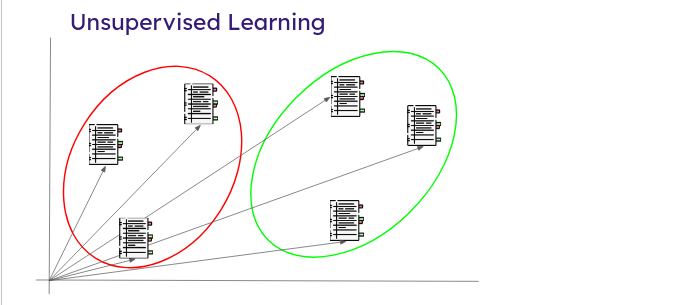

## **2.1. - Corpus No Etiquetado**

### Fake News Dataset

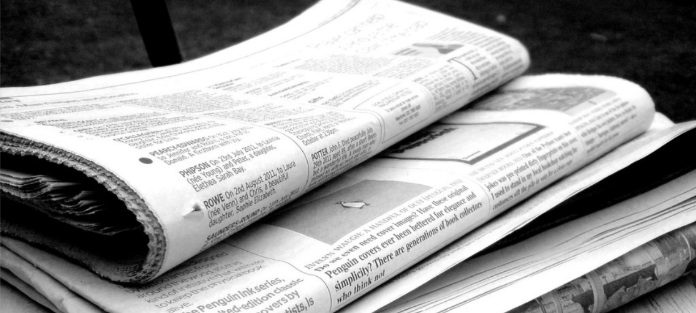

Fake news dataset es un corpus que contiene diferentes registros de textos de prensa escrita en español sobre diferentes noticias. Estos textos están etiquetados tanto con la temática de la noticia como con si la noticia es o no fake

In [8]:
import pandas as pd

df = pd.read_csv("hf://datasets/mariagrandury/fake_news_corpus_spanish/test.csv")
df

/home/thinbaker/Workspace/Curso-de-IA-y-NLP/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning:

IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html



,ID,CATEGORY,TOPICS,SOURCE,HEADLINE,TEXT,LINK
0,1,True,Covid-19,El Economista,Covid-19: mentiras que matan,El control de la Covid-19 no es sólo un tema d...,https://www.eleconomista.com.mx/opinion/Covid-...
1,2,False,Política,El matinal,El Gobierno podrá acceder a las IPs de los móv...,El Gobierno de Pedro Sánchez y Pablo Iglesias ...,https://www.elmatinal.com/espana-ultima-hora/e...
2,3,True,Política,El País,La comunidad musulmana catalana denuncia a Vox...,Las tres federaciones que agrupan al 90% de la...,https://elpais.com/espana/elecciones-catalanas...
3,4,False,Política,AFPFactual,NaN,Se han dado a conocer los datos electorales pr...,https://perma.cc/GYE6-SPMB
4,5,True,Sociedad,La Republica,El censo poblacional 2018 tendrá un costo de $...,La primera fase del censo será virtual y solo ...,https://www.larepublica.co/economia/el-censo-p...
...,...,...,...,...,...,...,...
567,568,True,Covid-19,El Financiero,Encuentran nueva variante de COVID en México: ...,El Instituto de Diagnóstico y Referencia Epide...,https://www.elfinanciero.com.mx/salud/encuentr...
568,569,False,Sociedad,diariogol,El móvil de más de 60.000 euros de la princesa...,La hija del rey Felipe y de la reina Letizia y...,https://www.diariogol.com/gossip/el-movil-de-m...
569,570,False,Política,AFPFactual,NaN,"Evidentemente, Barak Obama ha sido arrestado e...","Perma | Obama, Biden y la directora de la CIA,..."
570,571,True,Covid-19,Redacción Médica,Covid: las vacunas puestas en España no alcanz...,El Ministerio de Sanidad ha actualizado los da...,https://www.redaccionmedica.com/secciones/sani...


### Preprocesamiento

**Eliminar etiqueta de topics**: El dataset ya está categorizado por topics por lo que no tiene sentido aplicar con modelo de aprendizaje no-supervisado. Sin embargo nuestro objetivo es didático, así que para ello vamos a quedarnos con 3 topics a ver si el modelo es capaz de aprenderlos

In [9]:
df = df[df.TOPICS.apply(lambda x: x in ["Covid-19", 'Sociedad', 'Política'])]
df

,ID,CATEGORY,TOPICS,SOURCE,HEADLINE,TEXT,LINK
0,1,True,Covid-19,El Economista,Covid-19: mentiras que matan,El control de la Covid-19 no es sólo un tema d...,https://www.eleconomista.com.mx/opinion/Covid-...
1,2,False,Política,El matinal,El Gobierno podrá acceder a las IPs de los móv...,El Gobierno de Pedro Sánchez y Pablo Iglesias ...,https://www.elmatinal.com/espana-ultima-hora/e...
2,3,True,Política,El País,La comunidad musulmana catalana denuncia a Vox...,Las tres federaciones que agrupan al 90% de la...,https://elpais.com/espana/elecciones-catalanas...
3,4,False,Política,AFPFactual,NaN,Se han dado a conocer los datos electorales pr...,https://perma.cc/GYE6-SPMB
4,5,True,Sociedad,La Republica,El censo poblacional 2018 tendrá un costo de $...,La primera fase del censo será virtual y solo ...,https://www.larepublica.co/economia/el-censo-p...
...,...,...,...,...,...,...,...
567,568,True,Covid-19,El Financiero,Encuentran nueva variante de COVID en México: ...,El Instituto de Diagnóstico y Referencia Epide...,https://www.elfinanciero.com.mx/salud/encuentr...
568,569,False,Sociedad,diariogol,El móvil de más de 60.000 euros de la princesa...,La hija del rey Felipe y de la reina Letizia y...,https://www.diariogol.com/gossip/el-movil-de-m...
569,570,False,Política,AFPFactual,NaN,"Evidentemente, Barak Obama ha sido arrestado e...","Perma | Obama, Biden y la directora de la CIA,..."
570,571,True,Covid-19,Redacción Médica,Covid: las vacunas puestas en España no alcanz...,El Ministerio de Sanidad ha actualizado los da...,https://www.redaccionmedica.com/secciones/sani...


In [10]:
topics = df.TOPICS

Además vamos a hacer un preprocesamiento orientado a mantener palabras principales

In [11]:
import re
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

# Descarga los recursos de nltk (solo la primera vez)
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('punkt_tab')

# Función de preprocesamiento

def preprocess(text):

    stop_words = set(stopwords.words('spanish')) # Usa stopwords en español

    text = re.sub(r'\s+', ' ', text) # Elimina espacios extra

    text = re.sub(r'[^\w\s]', '', text) # Elimina signos de puntuación

    tokens = word_tokenize(text.lower()) # Tokeniza y convierte a minúsculas

    tokens = [word for word in tokens if word not in stop_words]

    return tokens


# Aplica el preprocesamiento a cada documento

corpus = df['TEXT'].tolist()

corpus = [" ".join(preprocess(doc)) for doc in corpus]

print(corpus[0][0:150])

print(corpus[1][0:150])


[nltk_data] Downloading package punkt to /home/thinbaker/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package stopwords to
[nltk_data]     /home/thinbaker/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     /home/thinbaker/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


control covid19 sólo tema médicos resto personal sanitario científico desgracia fortuna asunto esencialmente político decide hombres mujeres dedican p
gobierno pedro sánchez pablo iglesias encontrado excusa perfecta vulnerar privacidad españoles través norma sido diseñada controlar orden público call


### Vectorización de texto

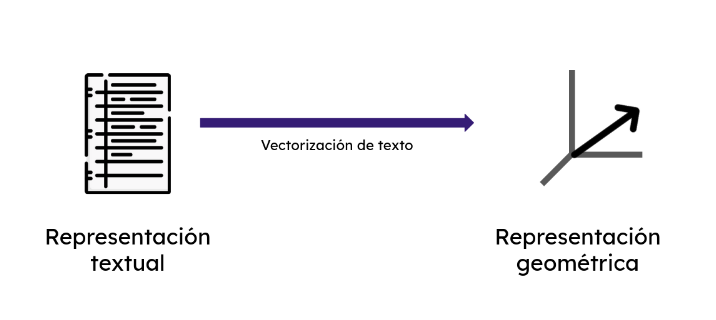

In [12]:
import nltk
import requests
nltk.download('stopwords')
from sklearn.feature_extraction.text import TfidfVectorizer


vectorizer = TfidfVectorizer(
    lowercase=True,
    analyzer='word',
    stop_words= nltk.corpus.stopwords.words('spanish'),
    ngram_range=(1, 1),
    min_df=0.01,
    max_df=0.80,
    max_features=1200,
).fit(corpus)

corpus_vectorized = vectorizer.transform(corpus)

[nltk_data] Downloading package stopwords to
[nltk_data]     /home/thinbaker/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


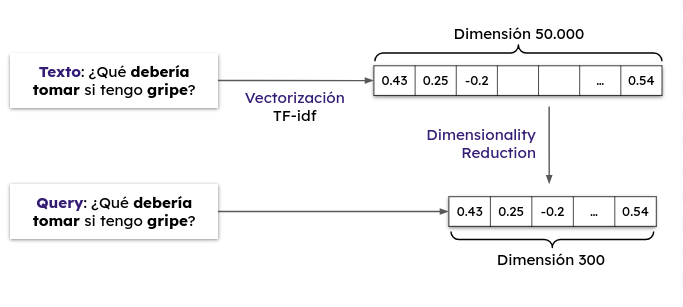

In [13]:
from sklearn.decomposition import PCA

dim_reducer = PCA(
    n_components=300,
    random_state=42
).fit(corpus_vectorized)

corpus_vectorized_reduced=dim_reducer.transform(corpus_vectorized)

corpus_vectorized_reduced.shape

(539, 300)

<br>

## 2.2. - Latent Semantic Analysis (LSA)

Otro tipo de forma de hacer Topic Modelling es por medio usar algoritmos de clustering tradicional sobre vectores de texto como por ejemplo TF-idf. Este tipo de técnica de topic modelling se denomina Latent Semantic Allocation

### Modelo Kmeans

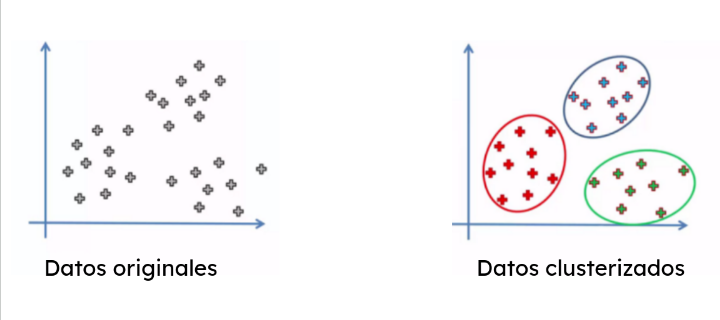

Dentro de los diferentes modelos que existen vamos a usar el algoritmo Kmeans

In [14]:
from sklearn.cluster import KMeans

model = KMeans(n_clusters= 3,  random_state=33)

model.fit(X=corpus_vectorized_reduced)

categories = model.labels_

categories

array([1, 0, 2, 2, 2, 1, 0, 2, 1, 1, 2, 1, 0, 1, 1, 0, 2, 1, 2, 2, 2, 0,
       1, 1, 0, 2, 0, 1, 2, 2, 2, 0, 1, 2, 1, 2, 0, 1, 1, 0, 2, 1, 2, 0,
       1, 1, 2, 2, 1, 1, 1, 1, 1, 0, 1, 2, 1, 2, 2, 1, 0, 1, 2, 0, 1, 1,
       2, 0, 2, 0, 2, 2, 1, 0, 0, 2, 2, 2, 1, 1, 0, 1, 2, 2, 1, 0, 2, 1,
       2, 1, 2, 1, 2, 0, 2, 1, 2, 0, 1, 2, 2, 2, 1, 2, 1, 0, 2, 1, 0, 1,
       2, 2, 2, 2, 1, 0, 1, 1, 1, 2, 0, 2, 1, 2, 1, 2, 1, 2, 2, 1, 1, 0,
       2, 0, 2, 2, 0, 2, 1, 1, 1, 1, 2, 2, 1, 2, 2, 1, 1, 1, 2, 0, 2, 1,
       1, 1, 1, 2, 2, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 2, 1, 0, 1, 2, 2, 1,
       2, 1, 1, 0, 1, 1, 2, 2, 2, 2, 2, 1, 1, 1, 1, 2, 1, 1, 0, 1, 2, 1,
       1, 1, 1, 1, 2, 0, 1, 2, 2, 1, 1, 2, 2, 0, 1, 1, 2, 1, 1, 1, 2, 2,
       1, 1, 2, 1, 1, 1, 1, 1, 0, 2, 1, 0, 1, 0, 1, 2, 0, 1, 1, 1, 0, 1,
       1, 1, 0, 2, 2, 2, 2, 0, 0, 1, 0, 2, 1, 0, 0, 0, 1, 2, 2, 2, 1, 2,
       1, 2, 2, 2, 1, 0, 0, 0, 2, 0, 0, 1, 2, 1, 2, 1, 2, 2, 0, 2, 2, 1,
       1, 2, 2, 2, 1, 1, 1, 0, 0, 1, 1, 1, 2, 1, 2,

<br>

### Evaluación

In [15]:

topics, unique_categories = pd.factorize(df.TOPICS)
print(unique_categories.values)
print(topics[0:20])

<ArrowStringArray>
['Covid-19', 'Política', 'Sociedad']
Length: 3, dtype: str
[0 1 1 1 2 0 1 0 0 0 2 0 1 0 0 2 2 0 2 1]


In [16]:
import pandas as pd
from sklearn.metrics import silhouette_score
from sklearn.metrics import adjusted_rand_score


silhouette_avg = silhouette_score(corpus_vectorized_reduced, categories)
print("Silhouette Score:", silhouette_avg)


ari_score = adjusted_rand_score(topics, categories)
print("Adjusted Rand Index (ARI):", ari_score)

Silhouette Score: 0.014883965328007962
Adjusted Rand Index (ARI): 0.39129549856184037


<br>

**Confussion Matrix**

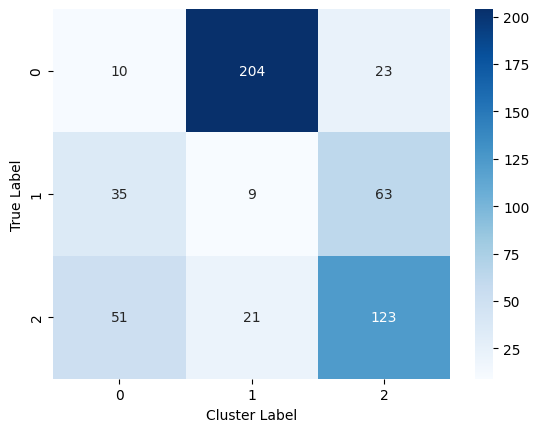

In [17]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

conf_matrix = confusion_matrix(topics, categories)

sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues')

plt.xlabel('Cluster Label')

plt.ylabel('True Label')

plt.show()

<br>

### Ejercicio - Algoritmos de clustering

Probar otros algoritmos de Clustering a ver si conseguimos una mejor clusterización

<br>

# 3.0. - Language Model

Los modelos de lenguaje son modelso que tratan de "generar" lenguaje a partir de haber "leído" un corpus. Este tipo de modelos aprenden a predecir la siguiente palabra más probable a partir de las N palabras anteriores

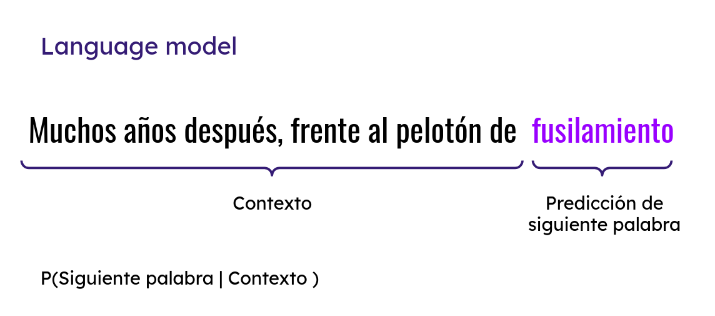

> **NOTA**: Los modelos de lenguaje realmente no se consideran un modelo de aprendizaje no supervisado, ya que tienen features y tarjet (las features son una secuencia de palabras y el tarjet la siguiente palabra a predecir). Sin embargo, el hecho de que solamente necesiten texto natural sin etiquetar hace que muchas veces se les considere no-supervisado

## **3.1. - Corpus No Etiquetado**

### 100 años de soledad

In [18]:
import requests

# Web con el libro en txt
web = "https://gist.githubusercontent.com/ismaproco/6781d297ee65c6a707cd3c901e87ec56/raw/20d3520cd7c53d99215845375b1dca16ac827bd7/gabriel_garcia_marquez_cien_annos_soledad.txt"

# Descargamos con la librería request
response = requests.get(web)

# Recojemos el texto de descarga
text = response.text

# Combinar palabras cortadas
text = text.replace("- \n","")

# Pie de página
pie_de_pagina = "\n\n\nCien años de soledad \n\n\n\nGabriel García Márquez \n\n"

# Dividimos por pie de página
corpus = text.split(pie_de_pagina)[1:]

# Juntamos y dividimos por frase
corpus=' '.join(corpus).replace('\n','').split('. ')

corpus[0]

'Muchos años después, frente al pelotón de fusilamiento, el coronel Aureliano Buendía había de recordar aquella tarde remota en que su padre lo llevó a conocer el hielo'

<br>

## **3.2. - N-gramas**

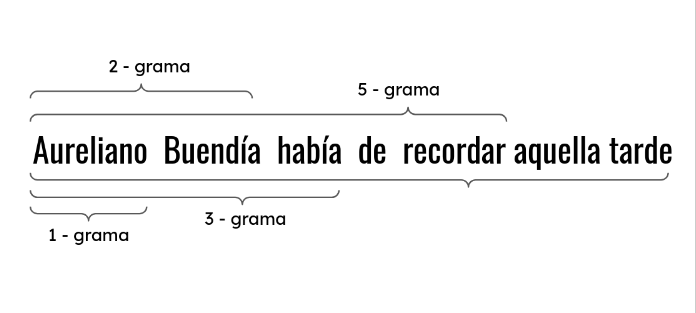

### Preprocesamiento

Para el preprocesamiento vamos a dejar palabras y únicamente aquellos signos más importantes para generar texto estructurado (i.e: . , ¡! ¿?)

In [19]:
import regex

def preprocess(text):

    # Cambiar saltos de línea dobles o más por simples
    text = regex.sub(r"\n\n+", "\n", text)

    # Eliminar puntuación excepto "." "," "!¡" y "¿?"
    text = regex.sub(r"[^\w\s.,!¡¿?]+", "", text)

    # Añadir espacio antes de los signos de puntuación
    text = regex.sub(r"([.,!¡¿?])", r" \1", text)

    # Replazar números por XXX
    text = regex.sub(r"\d+", "XXX", text)

    # Minúsculas
    text = text.lower()

    return text.split()

corpus_preprocessed = [preprocess(text) for text in corpus]
print(corpus_preprocessed[0])

['muchos', 'años', 'después', ',', 'frente', 'al', 'pelotón', 'de', 'fusilamiento', ',', 'el', 'coronel', 'aureliano', 'buendía', 'había', 'de', 'recordar', 'aquella', 'tarde', 'remota', 'en', 'que', 'su', 'padre', 'lo', 'llevó', 'a', 'conocer', 'el', 'hielo']


<br>

### Tokenización

**Vocabulario**

Los modelos de lenguaje suelen usar gran cantidad de textos que muchas veces contienen nuevo lenguaje. Es por ello por lo que lo más común es generar el vocabulario a partir del corpus

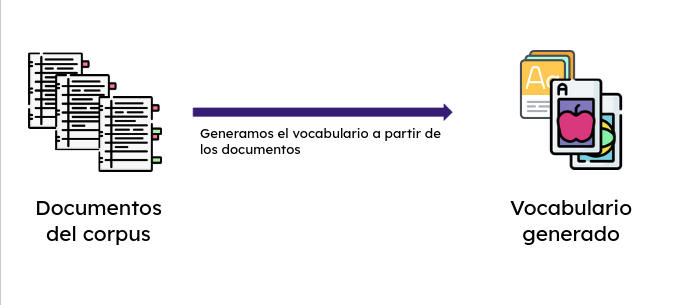

In [32]:
import pandas as pd
from nltk.lm import MLE
from nltk.lm.preprocessing import pad_both_ends
from nltk.lm.preprocessing import padded_everygram_pipeline


corpus_tokenized, vocab = padded_everygram_pipeline(
    order=4,
    text=corpus_preprocessed[0:500],
)

vocab = list(sorted(set([i for i in vocab])))
print(f"Corpus vocab:\n{vocab[0:100]}")

Corpus vocab:
['!', ',', '.', '</s>', '<s>', '?', 'a', 'abalorios', 'abandonado', 'abandonados', 'abandonar', 'abandonaron', 'abandonó', 'abastecerse', 'abejas', 'abierta', 'abiertas', 'abierto', 'abiertos', 'abismo', 'abnegación', 'abriendo', 'abrir', 'abrió', 'abrumados', 'absoluta', 'absoluto', 'absorbente', 'absorta', 'absorto', 'absurdo', 'abuelo', 'abuelos', 'aburrido', 'acababa', 'acaban', 'acabara', 'acacias', 'acamparon', 'accesorios', 'aceitada', 'aceite', 'aceites', 'acento', 'aceptar', 'acercaban', 'acierto', 'acomodada', 'acompañada', 'acompañado', 'acompañaron', 'acompañó', 'acontecimiento', 'acorazados', 'acordarse', 'acordes', 'acostada', 'acostarse', 'acostó', 'acosó', 'activa', 'actividad', 'activo', 'acto', 'actual', 'acuerdo', 'acumulado', 'acuosa', 'acuática', 'adelante', 'además', 'adentrarse', 'adherido', 'adiestrarlos', 'adivinaba', 'adivinando', 'admirables', 'admiración', 'admitió', 'adolescente', 'adornadas', 'adquirió', 'adversas', 'advertido', 'aflicción', 

<br>

**Tokenización**

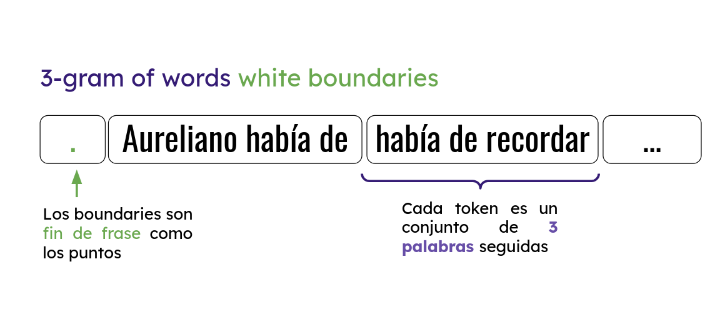

In [33]:
corpus_tokenized = [[gram for gram in sentence] for sentence in corpus_tokenized]
print(f"Corpus tokenized:\n{corpus_tokenized[0:100]}\n\n")

Corpus tokenized:
[[('<s>',), ('<s>', '<s>'), ('<s>', '<s>', '<s>'), ('<s>', '<s>', '<s>', 'muchos'), ('<s>',), ('<s>', '<s>'), ('<s>', '<s>', 'muchos'), ('<s>', '<s>', 'muchos', 'años'), ('<s>',), ('<s>', 'muchos'), ('<s>', 'muchos', 'años'), ('<s>', 'muchos', 'años', 'después'), ('muchos',), ('muchos', 'años'), ('muchos', 'años', 'después'), ('muchos', 'años', 'después', ','), ('años',), ('años', 'después'), ('años', 'después', ','), ('años', 'después', ',', 'frente'), ('después',), ('después', ','), ('después', ',', 'frente'), ('después', ',', 'frente', 'al'), (',',), (',', 'frente'), (',', 'frente', 'al'), (',', 'frente', 'al', 'pelotón'), ('frente',), ('frente', 'al'), ('frente', 'al', 'pelotón'), ('frente', 'al', 'pelotón', 'de'), ('al',), ('al', 'pelotón'), ('al', 'pelotón', 'de'), ('al', 'pelotón', 'de', 'fusilamiento'), ('pelotón',), ('pelotón', 'de'), ('pelotón', 'de', 'fusilamiento'), ('pelotón', 'de', 'fusilamiento', ','), ('de',), ('de', 'fusilamiento'), ('de', 'fusilamien

<br>

### Entrenamiento

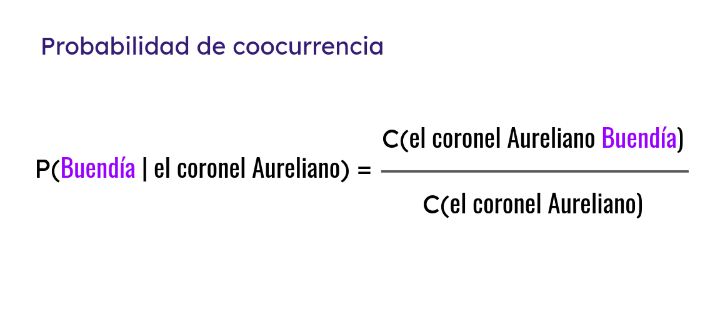

In [22]:
def lm_training(corpus_tokenized):

    # Separamos features (n-1 words) y tarjet (word n)
    features_list = []
    tarjet_list = []
    for sentence_grams in corpus_tokenized:
        for gram in sentence_grams:
            if len(gram) > 1:
                features_list.append(" ".join(gram[:-1]))
                tarjet_list.append(gram[-1])

    # Calculamos la matriz de coocurrencia
    coocurrence_pairs = pd.DataFrame({"features": features_list,"tarjet": tarjet_list})
    coocurrence_matrix = (
        coocurrence_pairs.groupby(["features","tarjet"])
        .size()
        .reset_index(name='count')
        .pivot(index='features', columns='tarjet', values='count').fillna(0)
        )

    return coocurrence_matrix

coocurrence_matrix = lm_training(corpus_tokenized)
coocurrence_matrix

tarjet,!,",",.,</s>,<s>,?,a,abalorios,abandonado,abandonados,...,óxido,úlceras,última,último,últimos,única,único,únicos,úrsula,útiles
features,,,,,,,,,,,,,,,,,,,,,
!,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
"! ,",0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
"! , le",0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
! gritó,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
! gritó </s>,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
úrsula y,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
úrsula y los,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
útiles,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


<br>

### Generación

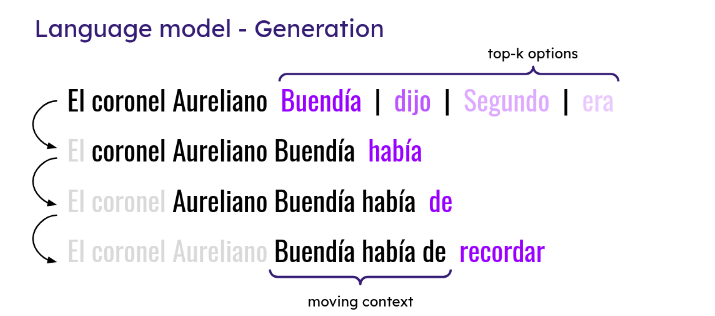

In [23]:
import random

def lm_generation(
    prompt,
    max_tokens=100,
):

    prompt = preprocess(prompt)

    response = {"tokens": prompt, "probs": [1.0]*len(prompt)}
    for _ in range(max_tokens):

        # Empezamos buscando del ngrama más grande al más pequeño
        for n in [3, 2, 1]:
            last_n_gram = " ".join(response["tokens"][-n:])

            if last_n_gram in coocurrence_matrix.index:

                # Extraer la fila de frecuencias
                coocurrences = coocurrence_matrix.loc[last_n_gram]

                # Convertir frecuencias a probabilidades
                token_probs = coocurrences / coocurrences.sum()

                # Muestreo estocástico
                most_probable_token = random.choices(
                    population=token_probs.index,
                    weights=token_probs.values,
                )[0]


                # Si el modelo predice el token de fin de frase de NLTK
                if most_probable_token == '</s>':
                    return response

                response["tokens"].append(most_probable_token)
                response["probs"].append(float(token_probs[most_probable_token]))
                break

    return response

In [24]:
prompt = "muchos años"

for i in range(5):
    resultado = lm_generation(prompt=prompt,max_tokens=30)["tokens"]
    resultado = " ".join(resultado)
    print(f"Resultado {i}:\n{resultado}\n\n")

Resultado 0:
muchos años después , cuando macondo fue un campamento de casas de madera y techos de cinc , todavía perduraban en las calles más antiguas los almendros rotos y polvorientas , aunque


Resultado 1:
muchos años después , frente al pelotón de fusilamiento , el coronel aureliano buendía volvió a travesar la región , inclusive el fondo del río , arrastrando los dos lingotes imantados


Resultado 2:
muchos años más tarde , cuando arreglara sus asuntos , y hasta sintió por él un poco de piedad , la mañana en que lo encontró lavándose las heridas en su propio


Resultado 3:
muchos años después , durante la segunda guerra civil , el coronel aureliano buendía volvió a vivir la tibia tarde de marzo en que su padre los llevara a conocer la portentosa


Resultado 4:
muchos años más tarde , un segundo antes de que nadie entrara en el cuarto vecino , el asma de las gallinas en el patio y vio a prudencio aguilar




<br>

In [25]:
resultado = lm_generation(prompt="el coronel Aureliano Maldía",max_tokens=30)
resultado

{'tokens': ['el', 'coronel', 'aureliano', 'maldía'],
 'probs': [1.0, 1.0, 1.0, 1.0]}

## 3.3 - Evaluación

### Perplexity

Esta métrica consiste en medir "cómo de probable" es la cadena que se genera. Para ello multiplicamos cada una de las probabilidades generadas elevado al inverso del número de tokens generados

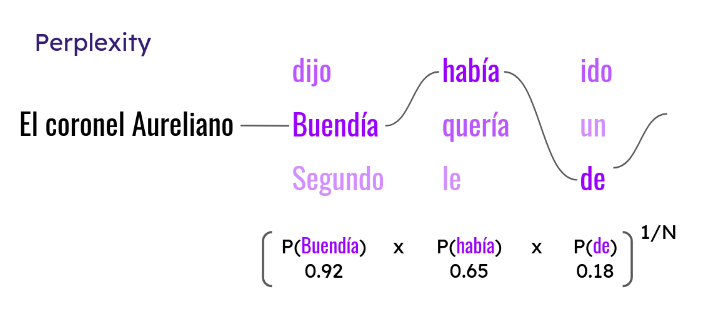

In [26]:
resultado = lm_generation(prompt="el coronel Aureliano",max_tokens=10)

print("Tokens: ",resultado["tokens"])
print("Probabilities:", resultado["probs"])

Tokens:  ['el', 'coronel', 'aureliano', 'buendía', 'volvió', 'a', 'vivir', 'la', 'tibia', 'tarde', 'de', 'marzo', 'en']
Probabilities: [1.0, 1.0, 1.0, 1.0, 0.5, 1.0, 0.5, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0]


In [27]:
import math

prompt = "muchos años"

for i in range(5):
    response = lm_generation(prompt=prompt,max_tokens=30)

    generation = " ".join(response["tokens"])
    print(f"Resultado {i}:\n{generation}")

    probs=response["probs"]
    perplexity = ((1 / len(probs)) * sum(math.log(p, 2) for p in probs))**2
    print(f"Perplexity: {perplexity}\n\n")

Resultado 0:
muchos años después , el coronel aureliano buendía volvió a travesar la región , cuando era ya una ruta regular del correo , y lo único que logró desenterrar fue una armadura
Perplexity: 0.07197420033084809


Resultado 1:
muchos años después , cuando macondo fue un campamento de casas de madera y techos de cinc , todavía perduraban en las calles un pánico de alborotada alegría , con sus loros
Perplexity: 0.015625


Resultado 2:
muchos años después , frente al pelotón de fusilamiento , el coronel aureliano buendía trató de hacer aquella misma ruta para tomarse a riohacha por sorpresa , y a los seis días
Perplexity: 0.019035699335974987


Resultado 3:
muchos años después , el coronel aureliano buendía trató de hacer aquella misma ruta para tomarse a riohacha por sorpresa , y a los seis días de viaje comprendió que era una
Perplexity: 0.03515625


Resultado 4:
muchos años después , durante la segunda guerra civil , el coronel aureliano buendía trató de hacer aquella misma rut

### BLEU, ROUGE Score

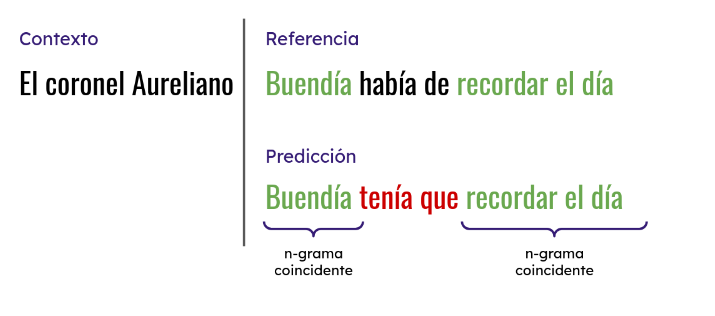

Estas métricas son análogas a las métricas de los modelos de clasificación precission y recall. Para ello tienen en cuenta los n-gramas coincidentes de la predicción y el texto de referencia

* **BLEU**(precission): `n-gramas coincidentes / n_gramas de predicción`

* **ROUGE**(recall): `n_gramas coincidentes / n_gramas de referencia`

In [34]:
#!pip install -q evaluate
#!pip install -q rouge_score

from evaluate import load

# Cargar las métricas ROUGE y BLEU
rouge_metric = load("rouge")
bleu_metric = load("bleu")

# Definir el prompt, la referencia y la predicción
prompt = "muchos años después"
reference = ", frente al pelotón de fusilamiento"
predicted = ", cuando Macondo fue un pueblo"

# Calcular el BLEU score (predicción vs referencia)
bleu_score = bleu_metric.compute(
    predictions=[predicted],  # Texto generado como cadena
    references=[[reference]]  # Texto de referencia como lista de cadenas
)

# Mostrar el resultado
print("BLEU Score:", bleu_score)

# Si también quieres calcular ROUGE:
rouge_score = rouge_metric.compute(
    predictions=[predicted],  # Texto generado
    references=[reference]    # Texto de referencia
)

print("ROUGE Score:", rouge_score)


BLEU Score: {'bleu': 0.0, 'precisions': [0.16666666666666666, 0.0, 0.0, 0.0], 'brevity_penalty': 1.0, 'length_ratio': 1.0, 'translation_length': 6, 'reference_length': 6}
ROUGE Score: {'rouge1': np.float64(0.0), 'rouge2': np.float64(0.0), 'rougeL': np.float64(0.0), 'rougeLsum': np.float64(0.0)}


Cálculo del BLEU de nuestras predicciones

In [35]:
#!pip install -q evaluate
#!pip install -q rouge_score
from evaluate import load

# Cargar la métrica ROUGE
rouge_metric = load("rouge")
bleu_metric = load("bleu")


prompt = "muchos años después"
reference = ", frente al pelotón de fusilamiento"

for i in range(5):

    response = lm_generation(prompt=prompt,max_tokens=6)
    generation = " ".join(response["tokens"])
    print(f"Resultado {i}:\n{generation}")

    bleu_score = bleu_metric.compute(
        predictions=[" ".join(response["tokens"][3:])],
        references=[[reference]],
    )
    print(f"BLEU: {bleu_score}")

    rouge_score = rouge_metric.compute(
        predictions=[" ".join(response["tokens"][3:])],
        references=[[reference]],
    )
    print(f"ROUGE: {rouge_score}\n\n")

Resultado 0:
muchos años después , cuando macondo fue un campamento
BLEU: {'bleu': 0.0, 'precisions': [0.16666666666666666, 0.0, 0.0, 0.0], 'brevity_penalty': 1.0, 'length_ratio': 1.0, 'translation_length': 6, 'reference_length': 6}
ROUGE: {'rouge1': np.float64(0.0), 'rouge2': np.float64(0.0), 'rougeL': np.float64(0.0), 'rougeLsum': np.float64(0.0)}


Resultado 1:
muchos años después , cuando macondo fue un campamento
BLEU: {'bleu': 0.0, 'precisions': [0.16666666666666666, 0.0, 0.0, 0.0], 'brevity_penalty': 1.0, 'length_ratio': 1.0, 'translation_length': 6, 'reference_length': 6}
ROUGE: {'rouge1': np.float64(0.0), 'rouge2': np.float64(0.0), 'rougeL': np.float64(0.0), 'rougeLsum': np.float64(0.0)}


Resultado 2:
muchos años después , el coronel aureliano buendía trató
BLEU: {'bleu': 0.0, 'precisions': [0.16666666666666666, 0.0, 0.0, 0.0], 'brevity_penalty': 1.0, 'length_ratio': 1.0, 'translation_length': 6, 'reference_length': 6}
ROUGE: {'rouge1': np.float64(0.0), 'rouge2': np.float64(0

> **NOTA**: Este tipo de métricas se utilizan especialmente para evaluar sistemas de traducción, sin embargo, se puede aplicar a cualquier problema de texto donde tengamos un texto generado y su equivalente texto de referencia

<br>

# Ejercicio - Translation Model with Parallel Corpus

## Parallel Corpus

Un parallel corpus (o corpus paralelo) es un conjunto de textos en dos o más idiomas que están alineados entre sí, es decir, cada fragmento en un idioma corresponde directamente con su traducción en otro. Gracias a esta alineación, los sistemas de inteligencia artificial pueden aprender equivalencias léxicas, patrones sintácticos y contextos de uso entre distintos idiomas.

In [30]:
import io
import zipfile
import requests
import pandas as pd

r = requests.get(
    "https://www.manythings.org/anki/spa-eng.zip",
    headers={"User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/91.0.4472.124 Safari/537.36"},
)

z = zipfile.ZipFile(io.BytesIO(r.content))
z.extractall()

# Cargamos el archivo extraído
df = pd.read_csv('spa.txt', sep='\t', header=None, names=['en', 'es', 'attr']).sample(frac=1,random_state=42)
df.head()

,en,es,attr
31486,It's too far to walk.,Es demasiado lejos para ir andando.,CC-BY 2.0 (France) Attribution: tatoeba.org #2...
93534,Come over here and give me a kiss.,Ven para acá y dame un beso.,CC-BY 2.0 (France) Attribution: tatoeba.org #3...
74169,Tom's remark was insensitive.,La observación de Tom fue insensible.,CC-BY 2.0 (France) Attribution: tatoeba.org #3...
106812,There's someone I'd like you to meet.,Hay alguien que me gustaría que conocierais.,CC-BY 2.0 (France) Attribution: tatoeba.org #1...
71409,I have just finished my work.,Recién acabo de terminar mi trabajo.,CC-BY 2.0 (France) Attribution: tatoeba.org #2...


El objetivo de esta tarea es hacer un sistema de traducción automática basado en tablas de coocurrencia, pero esta vez no entre una palabra y la siguiente sino entre una palabra y su traducción